# Explain UFR3: TOPS Time-Frequency Flow

## Navigation

- [Overall](./tops_azimuth_overall.md)
- Related notes:
  - [Azimuth Frequency Folding](./azimuth_freq_folding.md)
  - [Azimuth Frequency UFR](./azimuth_freq_ufr.md)
  - [Azimuth Compression](./azimuth_compression.md)
  - [Azimuth Time UFR](./azimuth_time_ufr.md)
- Companion note: [Explain UFR4](./explain_ufr4.md)

## Summary

- 這份 notebook 把 $\mathrm{explain\_UFR3.py}$ 改寫成教材型的 stage-by-stage flow。
- 前面只保留少量 setup；後面每一個 stage 都先跑出圖，再接著說這一步的數學與物理意義。
- 主線仍然是 $s_1(\eta) \rightarrow S_2(f_\eta) \rightarrow S_3(f_\eta) \rightarrow S_4(f_\eta) \rightarrow S_5(f_\eta) \rightarrow s_7(\eta) \rightarrow s_{7,\mathrm{mosaic}}(\eta) \rightarrow s_8(\eta) \rightarrow s_{8,\mathrm{unfolded}}(\eta) \rightarrow s_{\mathrm{final}}(\eta)$。

## Problem Definition

目標不是只把總圖搬進 notebook，而是把 frequency UFR、azimuth compression、time UFR 拆成可順著閱讀的教學步驟，讓讀者每看到一張 stage 圖，就能立刻看到這一步的數學與物理含義。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0b1020'
plt.rcParams['axes.facecolor'] = '#0b1020'
plt.rcParams['savefig.facecolor'] = '#0b1020'
plt.rcParams['axes.edgecolor'] = '#8aa1c1'
plt.rcParams['axes.labelcolor'] = '#d7e3f4'
plt.rcParams['text.color'] = '#eef4ff'
plt.rcParams['xtick.color'] = '#c9d5e6'
plt.rcParams['ytick.color'] = '#c9d5e6'


def plot_tf_view(signal_like, fs, title, y_limit, is_time_input=False, nfft=256, noverlap=200, cmap='turbo'):
    if is_time_input:
        time_sig = signal_like
    else:
        time_sig = np.fft.ifft(np.fft.ifftshift(signal_like))

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.specgram(time_sig, NFFT=nfft, Fs=fs, noverlap=noverlap, cmap=cmap, scale='linear')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Slow Time [eta] (s)')
    ax.set_ylabel('Doppler Freq [f_eta] (Hz)')
    ax.set_ylim(-y_limit, y_limit)
    fig.tight_layout()
    return fig

In [2]:
PRF = 1000.0
T_burst = 4.0
Naz = int(PRF * T_burst)

ks = 1000.0
ka = -500.0
T_dwell = 0.3
eta = np.linspace(-T_burst / 2, T_burst / 2, Naz, endpoint=False)

tc_array = np.linspace(-3.5, 3.5, 40)
raw_signal = np.zeros(Naz, dtype=complex)
for tc in tc_array:
    t_expo = (ka / (ka - ks)) * tc
    window = np.abs(eta - t_expo) <= (T_dwell / 2)
    target_phase = np.exp(1j * np.pi * ka * (eta - tc) ** 2)
    raw_signal[window] += target_phase[window]

print(f'Naz = {Naz}, PRF = {PRF:.0f} Hz, T_burst = {T_burst:.1f} s')
print(f'ka = {ka:.1f} Hz/s, ks = {ks:.1f} Hz/s, T_dwell = {T_dwell:.2f} s')

Naz = 4000, PRF = 1000 Hz, T_burst = 4.0 s
ka = -500.0 Hz/s, ks = 1000.0 Hz/s, T_dwell = 0.30 s


## Symbols And Assumptions

$\eta$: azimuth slow time
- $f_\eta$: azimuth frequency
- $T_{\mathrm{burst}}$: burst duration
- $\mathrm{PRF}$: azimuth sampling rate
- $N_{\mathrm{az}} = \mathrm{PRF} \cdot T_{\mathrm{burst}}$
- $k_a$: target azimuth FM rate
- $k_s$: scan-induced Doppler-centroid rate
- $T_{\mathrm{dwell}}$: illumination dwell time
- $t_c$: target focus-center label
- $t_{\mathrm{expo}}$: target exposure center
- $k_t = \dfrac{k_a k_s}{k_a - k_s}$: time-UFR chirp rate


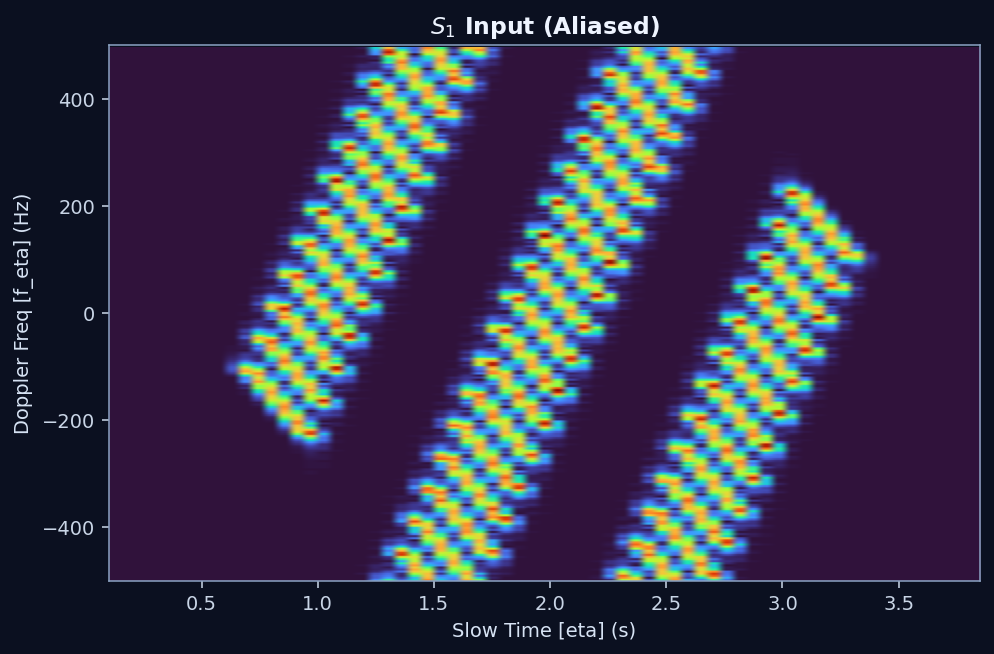

In [3]:
fig = plot_tf_view(
    raw_signal,
    PRF,
    r'$S_1$ Input (Aliased)',
    PRF / 2,
    is_time_input=True,
)
plt.show()

## 1. Input Aliased Signal

這張圖就是輸入 `s_1(eta)` 的 time-frequency view。每條斜 chirp trace 對應一個目標的 azimuth phase history，而它真正可見的時間區段是由 illumination window 決定，不是由 matched filter 決定。

Mathematical Step:

$$
w_p(\eta) = \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right)
$$

$$
s_{1,p}(\eta) = w_p(\eta) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
{\color{red} s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right) }
$$

$$
{\color{red} t_{\mathrm{expo},p} = \frac{k_a}{k_a-k_s} t_{c,p} }
$$

Physical Meaning:
TOPS 一開始改變的是目標被照亮的時刻 `t_expo`，而不是直接改變 matched filter 本身。這代表掃描幾何先把每個目標的有效觀測時間搬到不同位置，於是相同的 target chirp 會在不同曝光中心下進入後面的頻域處理。也正因為曝光中心和聚焦中心分離，後面才會自然出現 folding、mosaicking、再到 unfolding 的整條鏈。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$


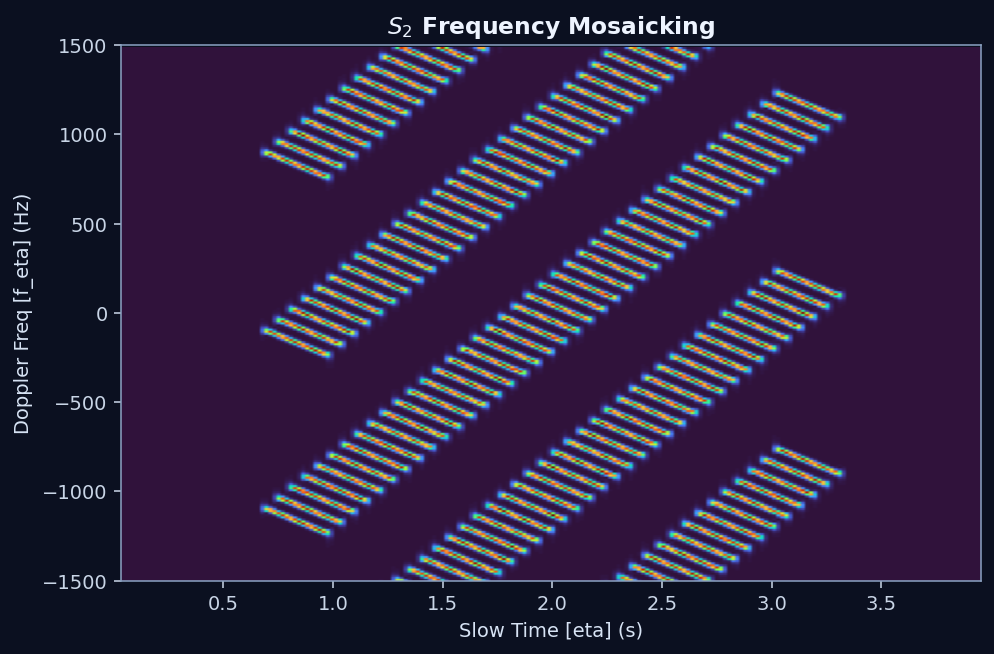

In [4]:
S1_aliased = np.fft.fftshift(np.fft.fft(raw_signal))
num_replicas = 3
S2 = np.tile(S1_aliased, num_replicas)
N_ufr = len(S2)
PRF_ufr = PRF * num_replicas
f_eta = np.linspace(-PRF_ufr / 2, PRF_ufr / 2, N_ufr, endpoint=False)

fig = plot_tf_view(
    S2,
    PRF_ufr,
    r'$S_2$ Frequency Mosaicking',
    PRF_ufr / 2,
)
plt.show()

## 2. Frequency Mosaicking

這一步把原本折在 principal PRF band 內的 replicas 沿 extended frequency axis 攤開，所以你看到的不再只是同一個主頻帶內互相覆疊的 clone，而是被排成一條更長的頻率軸。

Mathematical Step:

$$
S_1(f_\eta) = \mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
{\color{red} S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}) }
$$

Physical Meaning:
這一步本身沒有消除 aliasing，它只是把 folded replicas 從原來擠在 principal PRF band 的狀態攤到 extended frequency axis 上。物理上可以把它看成是先把原本重疊的觀測內容分開排隊，這樣下一步才有可能只對主 replica 做 reference-curvature 的處理，而不是在重疊狀態下硬切。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$


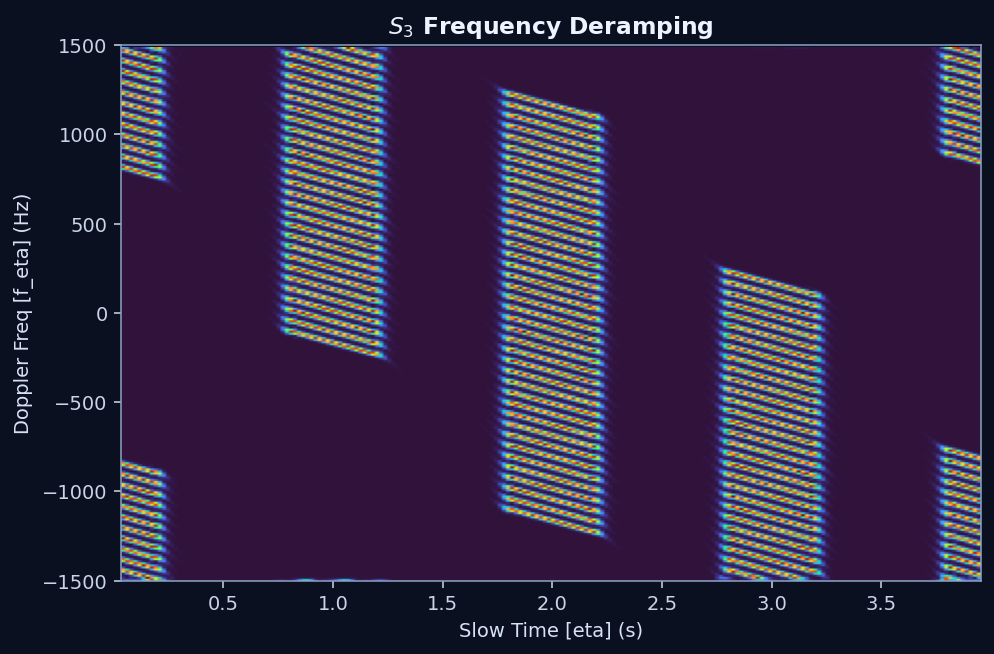

In [5]:
deramp_phase = np.exp(1j * np.pi * (1.0 / ks) * f_eta**2)
S3 = S2 * deramp_phase

fig = plot_tf_view(
    S3,
    PRF_ufr,
    r'$S_3$ Frequency Deramping',
    PRF_ufr / 2,
)
plt.show()

## 3. Frequency Deramping

在頻域 UFR 裡，這一步是先把主 replica 的 reference curvature 拿掉。圖上看起來像是原本彎曲的結構被壓平，因為主要想保留的那個 clone 已經被拉到更接近可裁切的形狀。

Mathematical Step:

$$
{\color{red} D_{\mathrm{de}}(f_\eta) = \exp\left( j\pi \frac{f_\eta^2}{k_s} \right) }
$$

$$
{\color{red} S_3(f_\eta) = S_2(f_\eta)\,D_{\mathrm{de}}(f_\eta) }
$$

Physical Meaning:
`k_s` 控制的是 scan-induced curvature。deramp 不是在做成像，而是在替下一步 LPF 造條件，因為主 replica 若不先被展平，固定 keep window 就無法穩定地只抓住中心 clone。從物理上看，這一步是在暫時移除由掃描造成的 reference quadratic phase，讓主 replica 在 pseudo-time domain 變得可裁切。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$


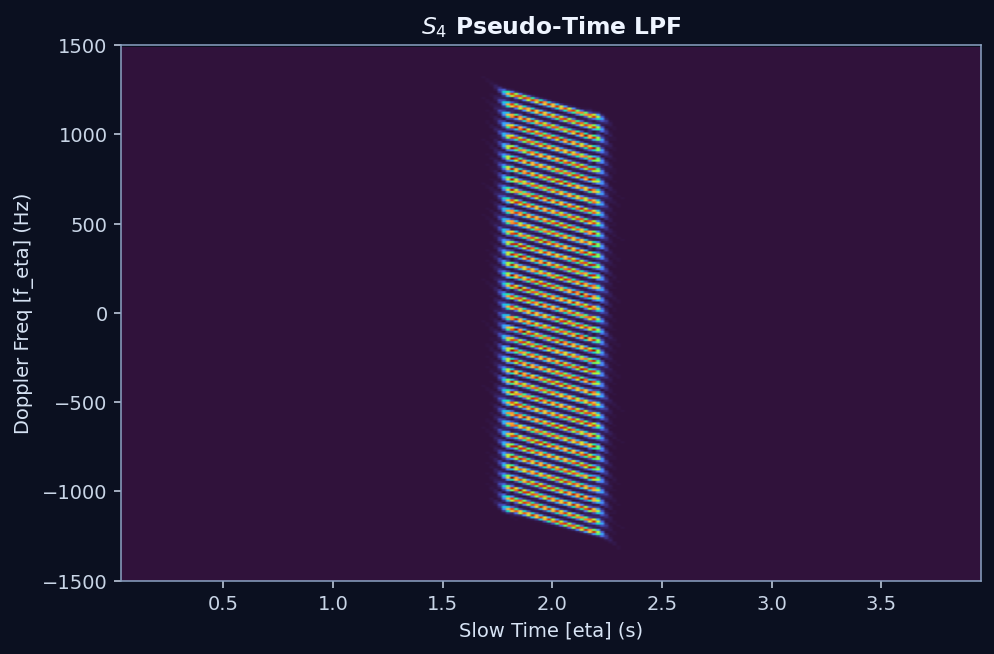

In [6]:
pseudo_time_signal = np.fft.fft(S3)
center_idx = N_ufr // 2
pts_to_keep = Naz // 2
pseudo_time_signal[:center_idx - pts_to_keep // 2] = 0
pseudo_time_signal[center_idx + pts_to_keep // 2:] = 0
S4 = np.fft.ifft(pseudo_time_signal)

fig = plot_tf_view(
    S4,
    PRF_ufr,
    r'$S_4$ Pseudo-Time LPF',
    PRF_ufr / 2,
)
plt.show()

## 4. Pseudo-Time LPF

這一步先把 `S_3` 轉進 pseudo-time domain，再把中央 keep window 之外的 clone 全部清掉，所以這裡才是真正把主 replica 單獨留下來的地方。

Mathematical Step:

$$
\widetilde{s}_3(\eta') = \mathcal{F}_{f_\eta}\left[S_3(f_\eta)\right]
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right)
$$

$$
{\color{red} S_4(f_\eta) = \mathcal{F}^{-1}_{f_\eta}\left[ \widetilde{s}_4(\eta') \right] }
$$

Physical Meaning:
這一步和頻域上的「只保留主 clone」完全對應。deramp 先讓主 replica 變平，LPF 才能用一個固定窗口把它切出來；如果前面不先 deramp，這個窗口就不會對得準。物理上，這一步代表系統正式丟棄非主 replica 的能量，讓後續鏈條只追蹤那個與主場景幾何一致的成分。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$


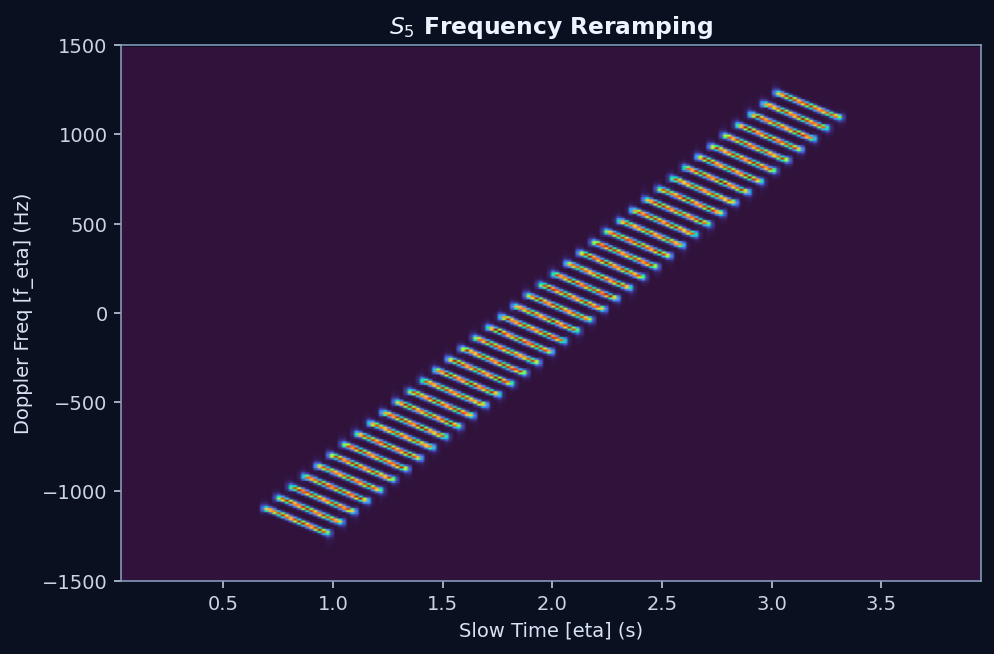

In [7]:
reramp_phase = np.exp(-1j * np.pi * (1.0 / ks) * f_eta**2)
S5 = S4 * reramp_phase

fig = plot_tf_view(
    S5,
    PRF_ufr,
    r'$S_5$ Frequency Reramping',
    PRF_ufr / 2,
)
plt.show()

## 5. Frequency Reramping

LPF 之後主 replica 已經被孤立出來，但它仍然處在被展平的 reference geometry 中，所以這一步要把 reference curvature 補回去，讓後續 matched filtering 面對的是幾何上正確的主 replica。

Mathematical Step:

$$
{\color{red} D_{\mathrm{re}}(f_\eta) = \exp\left( -j\pi \frac{f_\eta^2}{k_s} \right) }
$$

$$
{\color{red} S_5(f_\eta) = S_4(f_\eta)\,D_{\mathrm{re}}(f_\eta) }
$$

Physical Meaning:
reramp 只把主 replica 的 reference phase law 放回來，不會把之前被去掉的 clones 恢復。也就是說，幾何被補回，但 clone 不會復活。物理上，這一步是在保留「只有主 replica 還活著」這個結果的前提下，把它重新放回後續 azimuth compression 所需要的正確頻域相位幾何。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$


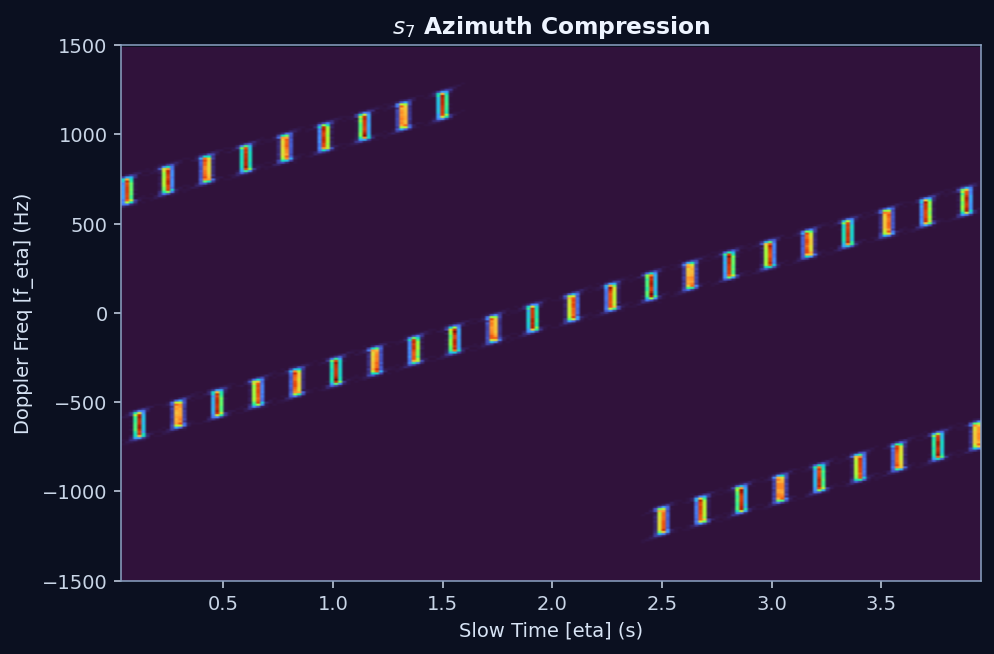

In [8]:
H_az = np.exp(1j * np.pi * (1.0 / ka) * f_eta**2)
S6 = S5 * H_az
s7_aliased_time = np.fft.ifft(np.fft.ifftshift(S6))

fig = plot_tf_view(
    s7_aliased_time,
    PRF_ufr,
    r'$s_7$ Azimuth Compression',
    PRF_ufr / 2,
    is_time_input=True,
)
plt.show()

## 6. Azimuth Compression

第一個 frequency UFR 到這裡已經完成，主 replica 也能被 matched filter 正常壓縮。但壓縮完之後，focused support 超出原始 `T_burst`，所以問題從頻率 aliasing 轉成時間 aliasing。

Mathematical Step:

$$
{\color{red} H_{\mathrm{az}}(f_\eta) = \exp\left( j\pi \frac{f_\eta^2}{k_a} \right) }
$$

$$
S_6(f_\eta) = S_5(f_\eta)H_{\mathrm{az}}(f_\eta)
$$

$$
{\color{red} s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_6(f_\eta)\right] }
$$

Physical Meaning:
`k_a` 這時候代表目標本身的 azimuth FM law。你已經把頻域 folding 解掉了，但 focus 後的 response 仍然可能超出時間窗，所以第二輪 UFR 變成必須在時間軸上再做一次。物理上，這一步說明第一輪 UFR 只解決了頻率域的摺疊，卻把能量壓縮回時間域之後的時間支撐問題顯露出來。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_5(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_a} \right)\right]
$$


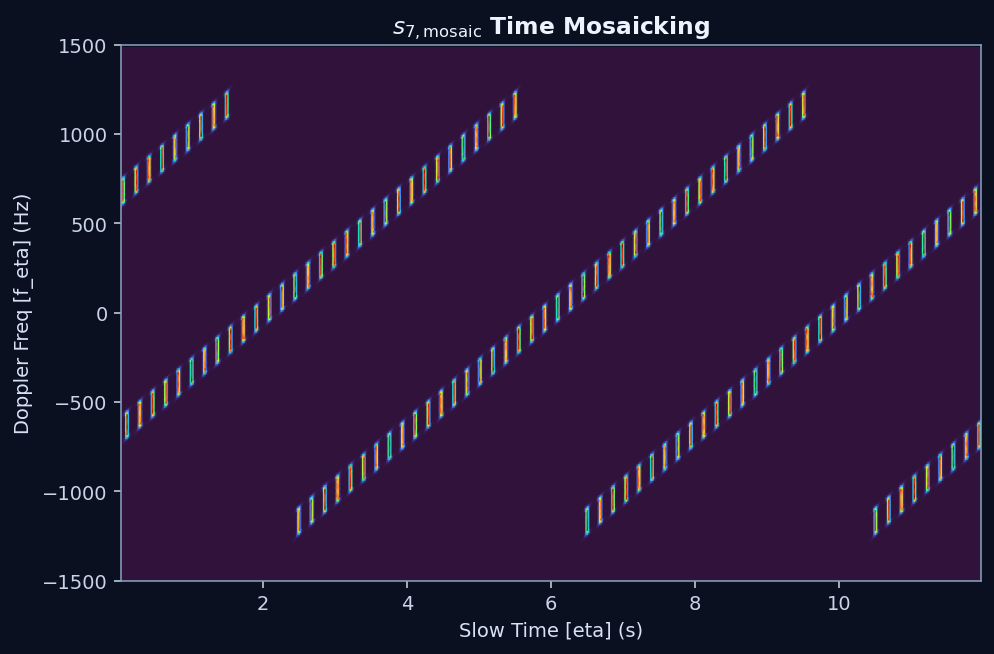

In [9]:
num_time_replicas = 3
s7_mosaic = np.tile(s7_aliased_time, num_time_replicas)
N_tufr = N_ufr * num_time_replicas
T_tufr = T_burst * num_time_replicas
eta_tufr = np.linspace(-T_tufr / 2, T_tufr / 2, N_tufr, endpoint=False)

fig = plot_tf_view(
    s7_mosaic,
    PRF_ufr,
    r'$s_{7,\mathrm{mosaic}}$ Time Mosaicking',
    PRF_ufr / 2,
    is_time_input=True,
)
plt.show()

## 7. Time Mosaicking

這一步在時間域扮演和前面 frequency mosaicking 完全平行的角色。既然 `s_7(eta)` 已經因為 circular wrap 而折回主時間窗，現在就先把它沿 extended timeline 攤開。

Mathematical Step:

$$
{\color{red} s_{7,\mathrm{mosaic}}(\eta) = \sum_{n=-1}^{1} s_7(\eta-nT_{\mathrm{burst}}) }
$$

Physical Meaning:
這一步不是在消除 aliasing，而是在把 wrapped timeline 排開，讓主時間 clone 能夠像之前的主頻率 replica 一樣，被單獨展平、裁切、再補回去。物理上，它和 frequency mosaicking 是完全平行的動作，只是座標已經從 `f_eta` 換成 `eta`，表示現在真正需要解的是聚焦後時間支撐超窗的問題。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_5(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_a} \right)\right]
$$

$$
s_{7,\mathrm{mosaic}}(\eta) = \sum_{n=-1}^{1} s_7(\eta-nT_{\mathrm{burst}})
$$


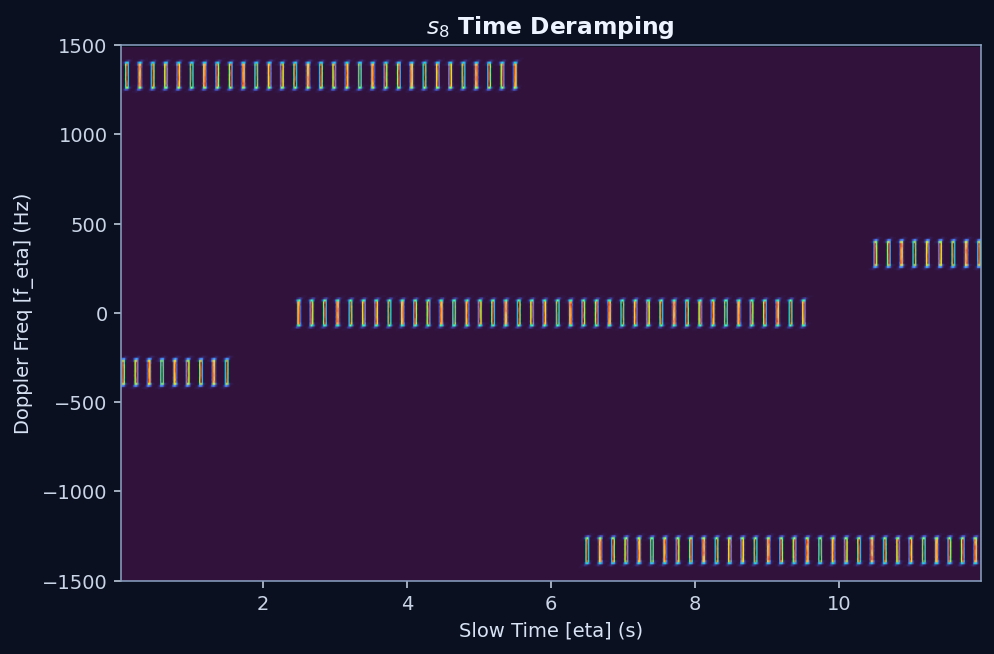

In [10]:
kt = (ka * ks) / (ka - ks)
deramp_phase_time = np.exp(-1j * np.pi * kt * eta_tufr**2)
s8_deramped = s7_mosaic * deramp_phase_time

fig = plot_tf_view(
    s8_deramped,
    PRF_ufr,
    r'$s_8$ Time Deramping',
    PRF_ufr / 2,
    is_time_input=True,
)
plt.show()

## 8. Time Deramping

現在要展平的對象不再是 frequency replica，而是時間軸上的主 clone，所以 reference curvature 也換成時間域的 `k_t`。圖上看到的變化，和前面 frequency deramp 是同一個邏輯，只是座標換了。

Mathematical Step:

$$
{\color{red} k_t = \frac{k_ak_s}{k_a-k_s} }
$$

$$
{\color{red} s_8(\eta) = s_{7,\mathrm{mosaic}}(\eta)\,\exp\left( -j\pi k_t\eta^2 \right) }
$$

Physical Meaning:
`k_t` 是時間 UFR 中真正要被拿掉的 quadratic curvature。這一步完成後，主時間 clone 會比較容易在頻域中央被 LPF 留下來。物理上，它扮演的是時間域版本的 reference-curvature removal，也就是先把主時間 clone 變成可用固定頻帶窗口捕捉的形狀，讓後面的 time LPF 有明確的主體可留。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_5(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_a} \right)\right]
$$

$$
s_{7,\mathrm{mosaic}}(\eta) = \sum_{n=-1}^{1} s_7(\eta-nT_{\mathrm{burst}})
$$

$$
s_8(\eta) = s_{7,\mathrm{mosaic}}(\eta)\exp\left(-j\pi k_t\eta^2\right), \quad k_t=\frac{k_a k_s}{k_a-k_s}
$$


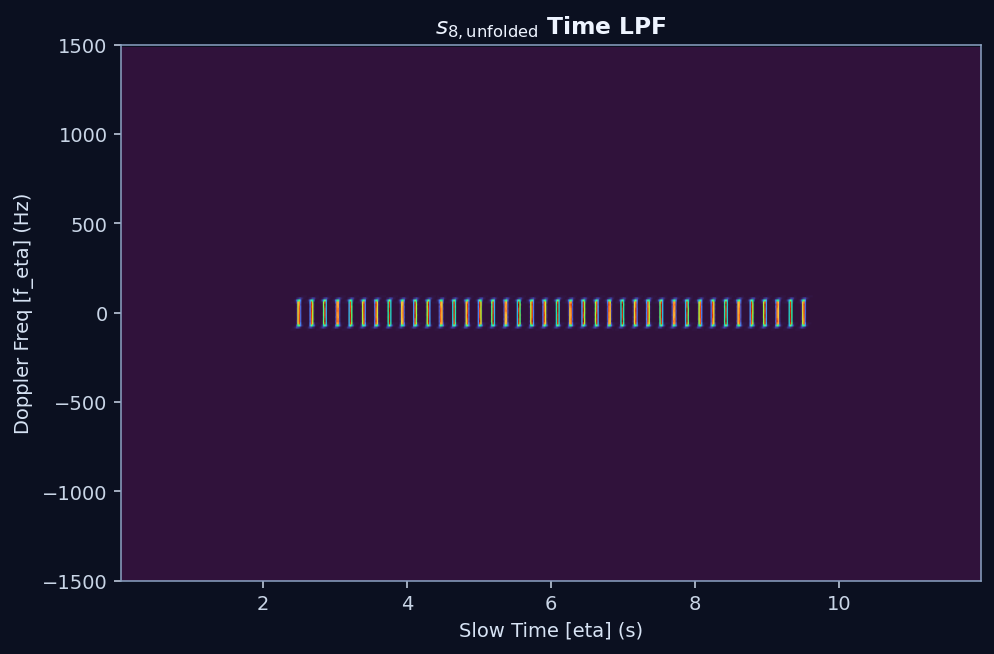

In [11]:
S8_freq = np.fft.fftshift(np.fft.fft(s8_deramped))
f_eta_tufr = np.linspace(-PRF_ufr / 2, PRF_ufr / 2, N_tufr, endpoint=False)
time_lpf_width = PRF * 0.35
time_lpf_mask = np.abs(f_eta_tufr) <= (time_lpf_width / 2)
S8_filtered = S8_freq * time_lpf_mask
s8_unfolded = np.fft.ifft(np.fft.ifftshift(S8_filtered))

fig = plot_tf_view(
    s8_unfolded,
    PRF_ufr,
    r'$s_{8,\mathrm{unfolded}}$ Time LPF',
    PRF_ufr / 2,
    is_time_input=True,
)
plt.show()

## 9. Time LPF

這一步和 pseudo-time LPF 完全對應。差別只是現在被保留的是 central PRF band 對應的主時間 clone，所以經過 LPF 之後，時間折返的其餘 clones 就被清掉了。

Mathematical Step:

$$
S_8(f_\eta) = \mathcal{F}_\eta\left[s_8(\eta)\right]
$$

$$
S_{8,\mathrm{LPF}}(f_\eta) = S_8(f_\eta)\,\mathrm{rect}\left( \frac{f_\eta}{B_{\mathrm{keep,time}}} \right)
$$

$$
{\color{red} s_{8,\mathrm{unfolded}}(\eta) = \mathcal{F}^{-1}_\eta\left[ S_{8,\mathrm{LPF}}(f_\eta) \right] }
$$

Physical Meaning:
這一步完成後，主時間 clone 已經被孤立，但幾何仍然停留在 deramped 狀態，所以最後還要做一次 time reramp 才能回到正確的 focused geometry。物理上，這一步就是時間 UFR 真正去掉 wrap-around clone 的核心操作，代表系統只留下與主聚焦回應相容的 central band，而把其他折返能量排除。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_5(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_a} \right)\right]
$$

$$
s_{7,\mathrm{mosaic}}(\eta) = \sum_{n=-1}^{1} s_7(\eta-nT_{\mathrm{burst}})
$$

$$
s_8(\eta) = s_{7,\mathrm{mosaic}}(\eta)\exp\left(-j\pi k_t\eta^2\right), \quad k_t=\frac{k_a k_s}{k_a-k_s}
$$

$$
s_{8,\mathrm{unfolded}}(\eta) = \mathcal{F}^{-1}_\eta\left[\mathcal{F}_\eta\left[s_8(\eta)\right]\,\mathrm{rect}\left(\frac{f_\eta}{B_{\mathrm{keep,time}}}\right)\right]
$$


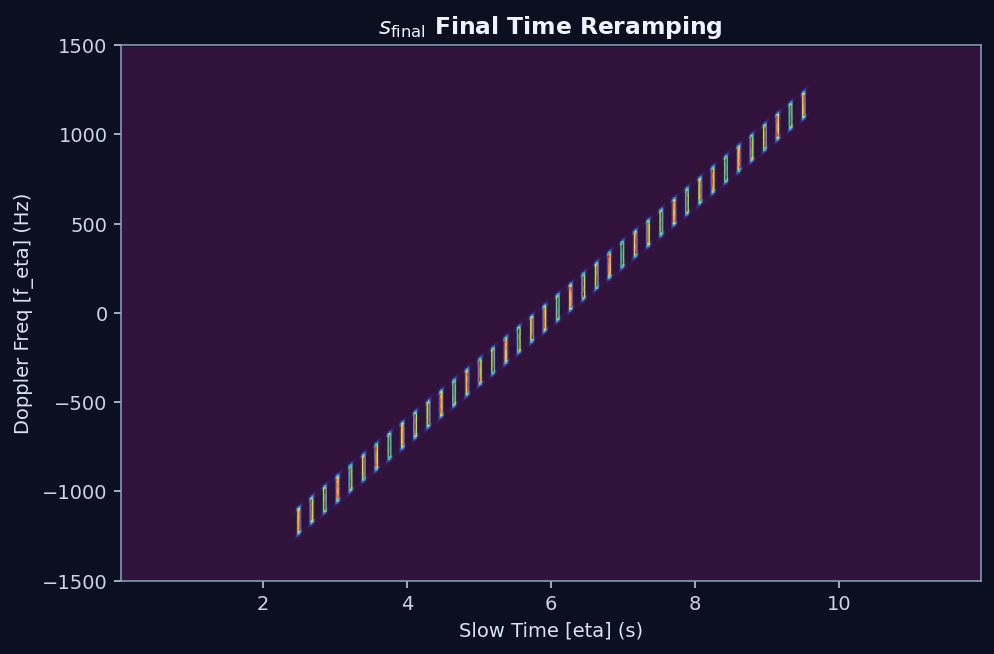

In [12]:
reramp_phase_time = np.exp(1j * np.pi * kt * eta_tufr**2)
s_final = s8_unfolded * reramp_phase_time

fig = plot_tf_view(
    s_final,
    PRF_ufr,
    r'$s_{\mathrm{final}}$ Final Time Reramping',
    PRF_ufr / 2,
    is_time_input=True,
)
plt.show()

## 10. Final Time Reramping

最後這一步把保留下來的主時間 clone 補回正確 curvature。做完之後，圖上留下的是 unaliased focused response，而不是先前那種被時間窗折回來的 wrap-around 結果。

Mathematical Step:

$$
{\color{red} s_{\mathrm{final}}(\eta) = s_{8,\mathrm{unfolded}}(\eta)\,\exp\left( j\pi k_t\eta^2 \right) }
$$

Physical Meaning:
到這裡 time aliasing 才真正被解除。前面做的 mosaicking、deramping、LPF 都是在為這個結果鋪路，也就是留下主 clone，然後把它恢復成正確的聚焦幾何。物理上，最終輸出不只是「看起來比較乾淨」，而是表示主聚焦回應已回到正確 curvature，因此它和先前的 alias-wrapped 結果在幾何意義上已經不是同一個訊號。

Accumulated Fully Expanded Closed Form:

$$
s_1(\eta) = \sum_p \mathrm{rect}\left( \frac{\eta-t_{\mathrm{expo},p}}{T_{\mathrm{dwell}}} \right) \exp\left( j\pi k_a(\eta-t_{c,p})^2 \right)
$$

$$
S_2(f_\eta) = \sum_{m=-1}^{1} S_1(f_\eta-m\cdot\mathrm{PRF}), \quad S_1(f_\eta)=\mathcal{F}_\eta\left[s_1(\eta)\right]
$$

$$
S_3(f_\eta) = S_2(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
\widetilde{s}_4(\eta') = \widetilde{s}_3(\eta')\,\mathrm{rect}\left( \frac{\eta'}{T_{\mathrm{keep}}} \right), \quad S_4(f_\eta)=\mathcal{F}^{-1}_{f_\eta}\left[\widetilde{s}_4(\eta')\right]
$$

$$
S_5(f_\eta) = S_4(f_\eta)\exp\left( -j\pi \frac{f_\eta^2}{k_s} \right)
$$

$$
s_7(\eta) = \mathcal{F}^{-1}_\eta\left[S_5(f_\eta)\exp\left( j\pi \frac{f_\eta^2}{k_a} \right)\right]
$$

$$
s_{7,\mathrm{mosaic}}(\eta) = \sum_{n=-1}^{1} s_7(\eta-nT_{\mathrm{burst}})
$$

$$
s_8(\eta) = s_{7,\mathrm{mosaic}}(\eta)\exp\left(-j\pi k_t\eta^2\right), \quad k_t=\frac{k_a k_s}{k_a-k_s}
$$

$$
s_{8,\mathrm{unfolded}}(\eta) = \mathcal{F}^{-1}_\eta\left[\mathcal{F}_\eta\left[s_8(\eta)\right]\,\mathrm{rect}\left(\frac{f_\eta}{B_{\mathrm{keep,time}}}\right)\right]
$$

$$
s_{\mathrm{final}}(\eta) = s_{8,\mathrm{unfolded}}(\eta)\exp\left(j\pi k_t\eta^2\right)
$$


## Final Result

這份 notebook 保留了 `explain_UFR3.py` 的細 stage 拆法，但把閱讀節奏改成教材型順序：先有少量 setup，然後每一步都先看到圖，再看到這一步的數學、關鍵 code、以及物理意義。

整條主線可以濃縮成：

$$
\text{input aliasing}
\Longrightarrow
\text{frequency UFR}
\Longrightarrow
\text{azimuth compression}
\Longrightarrow
\text{time aliasing}
\Longrightarrow
\text{time UFR}
$$

如果這份 notebook 的節奏成立，`UFR4` 就可以照同樣的教材型 pattern 擴展，而不需要再回到「先整張總圖，再補零散說明」的做法。